# Steel Industry Energy Consumption

Predicting and understanding electricity consumption at a steel plant, using the
UCI *Steel Industry Energy Consumption* dataset (DAEWOO Steel Co. Ltd, Gwangyang,
South Korea — 35,040 readings at 15-minute intervals across 2018).

This notebook follows the **CRISP-DM** process:

1. **Business Understanding** — why this matters and the questions we answer
2. **Data Understanding** — gather and assess the data (EDA)
3. **Data Preparation** — clean, handle missing/categorical values, select features
4. **Modeling** — Linear Regression and Random Forest
5. **Evaluation** — metrics, diagnostics, and answers to the business questions
6. **Deployment** — recommendations and how the results would be used

---
## Phase 1 — Business Understanding

A steel plant pays for every kilowatt-hour it draws, and utilities add penalties when
the *power factor* (how efficiently that power is used) is poor. Understanding and
predicting consumption supports budgeting, load scheduling toward cheaper tariff
windows, and emissions reporting.

We ask four business questions and answer each with a visual, table, or statistic:

- **Q1 — When does the plant consume the most energy?**
  (What daily and weekly patterns govern demand?)
- **Q2 — Which measurable electrical factors most strongly drive consumption?**
- **Q3 — Does the plant show power-factor inefficiency that signals avoidable cost?**
- **Q4 — Can we predict energy consumption accurately, and what is the honest
  performance ceiling of such a model?**

The dataset column `Usage_kWh` (energy consumed per 15-minute interval) is our
**target variable** throughout.

## Phase 2 — Data Understanding

### 2.1 Setup and gather the data
Install Ucim Report to import the dataset

In [1]:
pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

In [3]:
def load_steel_data():
    """Load the Steel Industry Energy Consumption dataset.

    import ucimlrepo, fetch data by id 851.

    Returns
    -------
    pandas.DataFrame
        The raw dataset with its original column names.
    """
    try:
        from ucimlrepo import fetch_ucirepo
        data = fetch_ucirepo(id=851).data.original.copy()
        print("Loaded via ucimlrepo")
    except Exception as error:
        print(f"ucimlrepo unavailable ({type(error).__name__}); reading local CSV")
        data = pd.read_csv("Steel_industry_data.csv")
    return data


df = load_steel_data()
df.head()

Loaded via ucimlrepo


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


### 2.2 Tidy the column names
Rename the long raw headers to concise, PEP8-friendly names so tables and plots stay readable.

In [4]:
def tidy_columns(data):
    """Return a copy of the dataframe with shortened, consistent column names.

    Parameters
    ----------
    data : pandas.DataFrame
        Raw dataset from :func:`load_steel_data`.

    Returns
    -------
    pandas.DataFrame
        Copy with renamed columns.
    """
    rename_map = {
        "Lagging_Current_Reactive.Power_kVarh": "Lagging_Reactive_kVarh",
        "Leading_Current_Reactive_Power_kVarh": "Leading_Reactive_kVarh",
        "CO2(tCO2)": "CO2_tCO2",
        "Lagging_Current_Power_Factor": "Lagging_PF",
        "Leading_Current_Power_Factor": "Leading_PF",
    }
    data = data.copy()
    data.columns = [c.strip() for c in data.columns]
    return data.rename(columns=rename_map)


df = tidy_columns(df)

# Numeric columns explored throughout; Usage_kWh is the target.
NUMERIC_COLS = [
    "Usage_kWh", "Lagging_Reactive_kVarh", "Leading_Reactive_kVarh",
    "CO2_tCO2", "Lagging_PF", "Leading_PF", "NSM",
]
TARGET = "Usage_kWh"
df.columns.tolist()

['date',
 'Usage_kWh',
 'Lagging_Reactive_kVarh',
 'Leading_Reactive_kVarh',
 'CO2_tCO2',
 'Lagging_PF',
 'Leading_PF',
 'NSM',
 'WeekStatus',
 'Day_of_week',
 'Load_Type']

### 2.3 Assess — data health check
Check shape, data types, missing values, and duplicate rows before trusting any statistic.
<br>This is the *assess* step of the data science process.

In [5]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (35040, 11)

Data types:
date                       object
Usage_kWh                 float64
Lagging_Reactive_kVarh    float64
Leading_Reactive_kVarh    float64
CO2_tCO2                  float64
Lagging_PF                float64
Leading_PF                float64
NSM                         int64
WeekStatus                 object
Day_of_week                object
Load_Type                  object
dtype: object

Missing values per column:
date                      0
Usage_kWh                 0
Lagging_Reactive_kVarh    0
Leading_Reactive_kVarh    0
CO2_tCO2                  0
Lagging_PF                0
Leading_PF                0
NSM                       0
WeekStatus                0
Day_of_week               0
Load_Type                 0
dtype: int64

Duplicate rows: 0


**Finding:** 35,040 rows × 11 columns, **zero missing values**, **zero duplicate
rows**. The data is complete — the implications for missing-value handling are
discussed in Phase 3.

### 2.4 Descriptive statistics
Percentiles and skew expose the tails; the zero-share table matters because several
columns are zero when the plant is idle.

In [6]:
stats = df[NUMERIC_COLS].describe(percentiles=[.01, .25, .5, .75, .99]).T
stats["skew"] = df[NUMERIC_COLS].skew()
stats.round(2)

,count,mean,std,min,1%,25%,50%,75%,99%,max,skew
Usage_kWh,35040.0,27.39,33.44,0.0,2.59,3.20,4.57,51.24,122.71,157.18,1.20
Lagging_Reactive_kVarh,35040.0,13.04,16.31,0.0,0.00,2.30,5.00,22.64,62.90,96.91,1.44
Leading_Reactive_kVarh,35040.0,3.87,7.42,0.0,0.00,0.00,0.00,2.09,26.39,27.76,1.73
CO2_tCO2,35040.0,0.01,0.02,0.0,0.00,0.00,0.00,0.02,0.06,0.07,1.15
Lagging_PF,35040.0,80.58,18.92,0.0,43.52,63.32,87.96,99.02,100.00,100.00,-0.61
Leading_PF,35040.0,84.37,30.46,0.0,15.57,99.70,100.00,100.00,100.00,100.00,-1.51
NSM,35040.0,42750.00,24940.53,0.0,0.00,21375.00,42750.00,64125.00,85500.00,85500.00,0.00


- Usage_kWh — median 4.6 vs mean 27.4: idles most of the time, long tail to 157. Right-skewed.
- Lagging_Reactive_kVarh — same shape (median 5, max 97); main production signal.
- Leading_Reactive_kVarh — zero up to the 75th percentile; idle-only signal.
- CO2_tCO2 — tiny (max 0.07), tracks Usage_kWh (derived from it).
- Lagging_PF — high (median 88) but dips to 43; low values = inefficiency flags. Left-skewed.
- Leading_PF — mostly ~100, tail to 15. Strongly left-skewed.
- NSM — uniform (skew 0): just the clock, evenly spaced all day.

Big picture: usage/reactive columns are right-skewed (idle-heavy plant), power factors left-skewed (usually efficient, occasional dips), NSM flat by design.

In [7]:
print("Percentage of exact zeros per column (structural zeros = plant idle):")
for col in NUMERIC_COLS:
    print(f"  {col:24s}: {(df[col] == 0).mean() * 100:5.1f}%")

Percentage of exact zeros per column (structural zeros = plant idle):
  Usage_kWh               :   0.0%
  Lagging_Reactive_kVarh  :  20.5%
  Leading_Reactive_kVarh  :  67.4%
  CO2_tCO2                :  59.9%
  Lagging_PF              :   0.0%
  Leading_PF              :   0.0%
  NSM                     :   1.0%


Zeros = how often each column is exactly zero:

- Usage_kWh, Lagging_PF, Leading_PF (0%) — always a baseline load; power factor is always defined.
- Lagging_Reactive_kVarh (20%) — zero when machinery is off (idle).
- Leading_Reactive_kVarh (67%) — only appears when idle, so zero most of the time.
- CO2_tCO2 (60%) — tiny usage rounds to zero tonnes.
- NSM (1%) — zero only at midnight (365 of 35,040 rows).

These are real "plant idle" signals, not missing data — so keep them.

### 2.5 The target variable: `Usage_kWh`

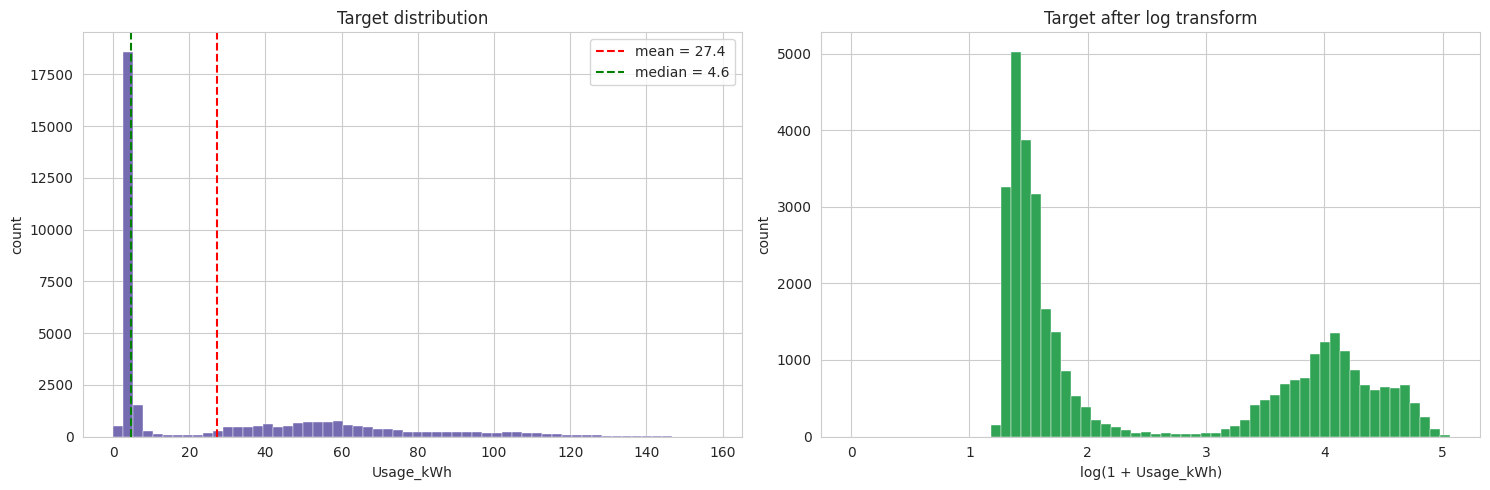

Skew (raw):   1.20
Skew (log1p): 0.49


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].hist(df[TARGET], bins=60, color="#756bb1", edgecolor="white", linewidth=.3)
ax[0].axvline(df[TARGET].mean(), color="red", ls="--",
              label=f"mean = {df[TARGET].mean():.1f}")
ax[0].axvline(df[TARGET].median(), color="green", ls="--",
              label=f"median = {df[TARGET].median():.1f}")
ax[0].set(xlabel="Usage_kWh", ylabel="count", title="Target distribution")
ax[0].legend()

ax[1].hist(np.log1p(df[TARGET]), bins=60, color="#31a354",
           edgecolor="white", linewidth=.3)
ax[1].set(xlabel="log(1 + Usage_kWh)", ylabel="count",
          title="Target after log transform")

plt.tight_layout()
plt.show()

print(f"Skew (raw):   {df[TARGET].skew():.2f}")
print(f"Skew (log1p): {np.log1p(df[TARGET]).skew():.2f}")

The target is strongly right-skewed (mean 27.4 far above median 4.6): the plant
idles most of the time, with a long tail of heavy-production intervals. A log
transform pulls it toward symmetry — useful context for the linear model.

### 2.6 Feature distributions

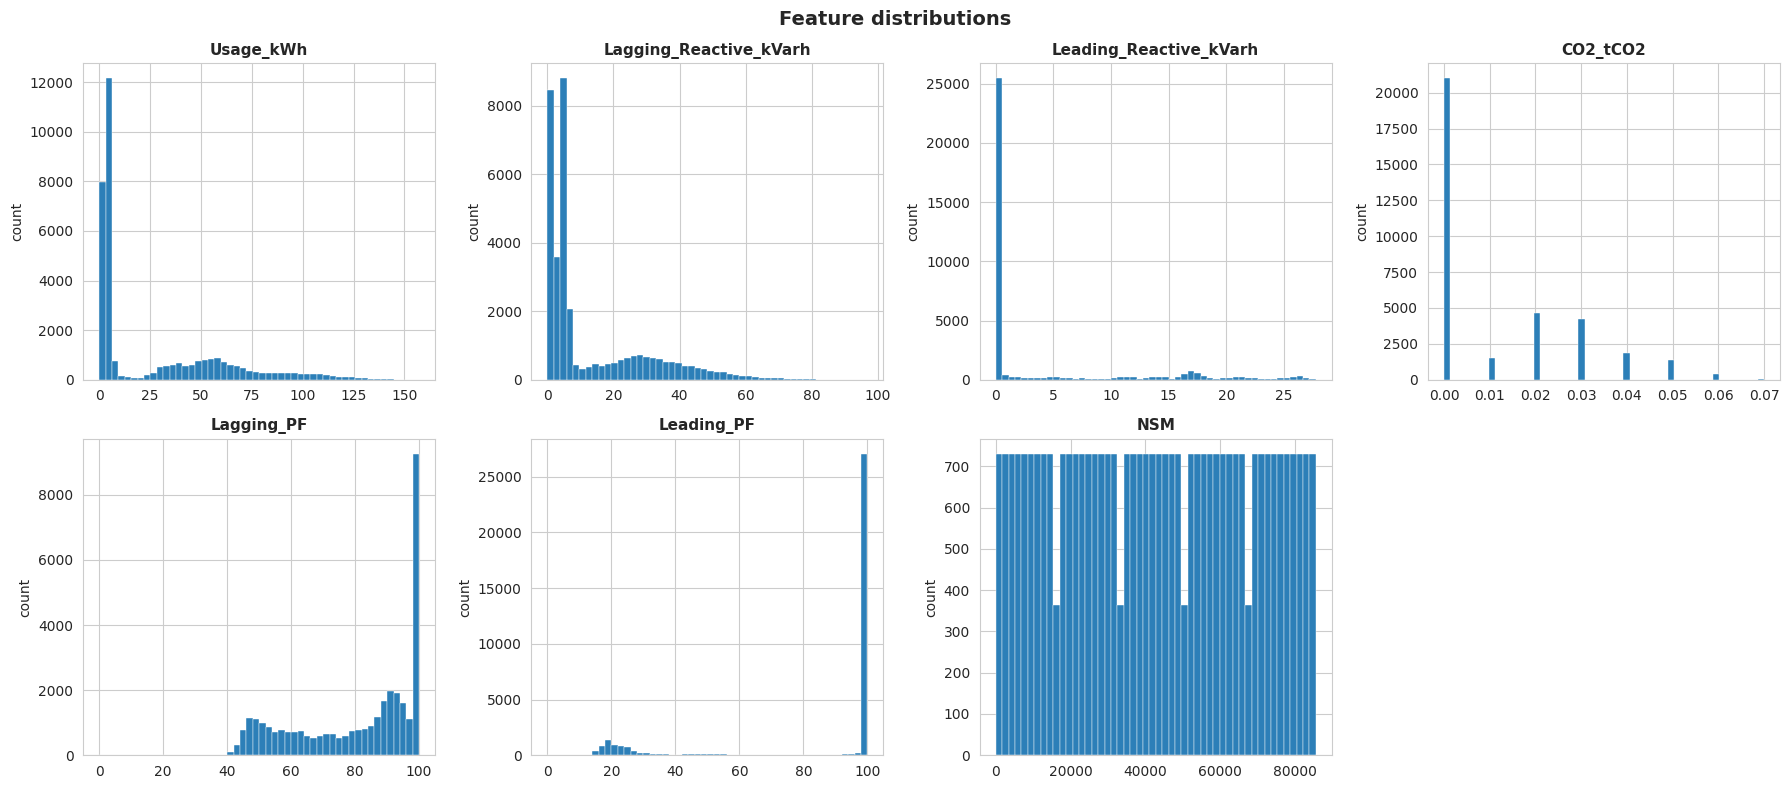

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    ax.hist(df[col], bins=50, color="#2c7fb8", edgecolor="white", linewidth=.3)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_ylabel("count")
axes.flat[-1].axis("off")
plt.suptitle("Feature distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

These histograms confirm the story from the stats:

- Usage_kWh, Lagging_Reactive_kVarh — huge spike near zero (plant idle), then a low, spread-out hump for production periods. Classic right skew.
- Leading_Reactive_kVarh, CO2_tCO2 — dominated by the zero bar; only small activity elsewhere. Idle-only / derived signals.
- Lagging_PF — piled up near 100 with a spread down to ~40. Mostly efficient, with inefficiency dips (left tail).
- Leading_PF — almost everything pinned at 100, tiny cluster near 20. Strong left skew.
- NSM — flat bars across the day (uniform); the gaps are just histogram binning against the discrete 15-min timestamps, not missing data.

Bottom line: the plant's idle-vs-producing split is visible in every column, and no distribution looks like a data error — the shapes are all physically expected.

### 2.7 Correlation structure
Correlation measures only *linear* association — we revisit non-linear shapes in the
scatter plots that answer Q2.

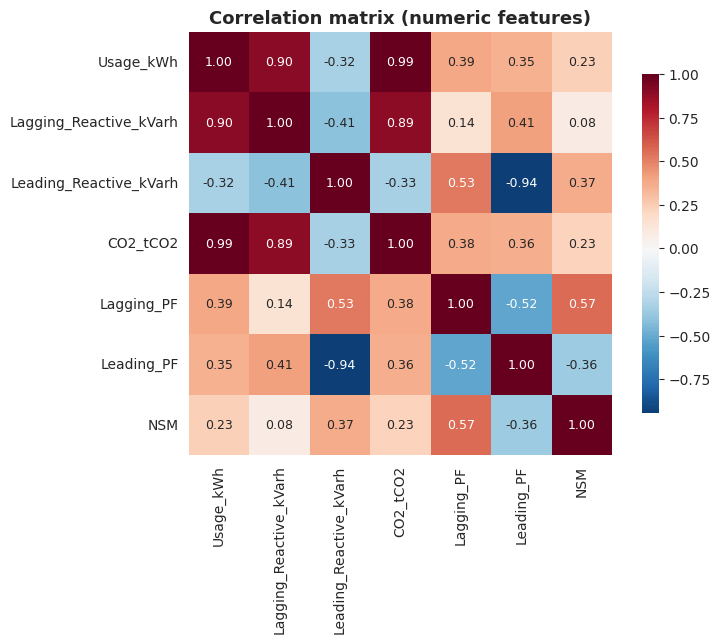

Correlation with target, sorted:
CO2_tCO2                  0.988
Lagging_Reactive_kVarh    0.896
Lagging_PF                0.386
Leading_PF                0.354
NSM                       0.235
Leading_Reactive_kVarh   -0.325
Name: Usage_kWh, dtype: float64


In [10]:
fig, ax = plt.subplots(figsize=(8, 6.5))
corr = df[NUMERIC_COLS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": .8}, annot_kws={"size": 9}, ax=ax)
ax.set_title("Correlation matrix (numeric features)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Correlation with target, sorted:")
print(corr[TARGET].drop(TARGET).sort_values(ascending=False).round(3))

Reading the correlations with the target (top row) and the key cross-relationships:

With Usage_kWh:

- CO2_tCO2 (0.99) — near-perfect, because it's derived from energy. Data leakage → drop it.
- Lagging_Reactive_kVarh (0.90) — strongest legitimate driver; core feature.
- Leading_Reactive_kVarh (−0.32) — negative; rises when the plant is idle.
- Lagging_PF (0.39), Leading_PF (0.35) — weak/moderate linearly (the real relationship is non-linear).
- NSM (0.23) — weak linearly, but strong non-linearly (the daytime hump).

Notable off-diagonal:

- Leading_Reactive_kVarh vs Leading_PF (−0.94) — almost redundant; they're two views of the same idle-capacitor behavior. Watch for multicollinearity in the linear model.
- Lagging_PF vs NSM (0.57) — efficiency is better during daytime production hours.

Takeaway: one leakage column to drop (CO2), one dominant honest predictor (lagging reactive power), and a couple of near-mirror pairs — all consistent with the idle-vs-producing split you've seen throughout.

## Phase 3 — Data Preparation

This phase documents **why** each cleaning and feature decision was made, as the
rubric requires.

### 3.1 Missing values
There are **no missing values** in any column (confirmed in 2.3), so no imputation
is required. Had values been missing, the appropriate approach for these continuous
sensor readings would have been median imputation (robust to the heavy right-skew).

### 3.2 Structural zeros are kept
`Leading_Reactive_kVarh` is zero 67% of the time, `CO2_tCO2` 60%, and
`Lagging_Reactive_kVarh` 20%. These are **not** errors or missing data — they occur
when the plant is idle and genuinely draws no such power. They are left untouched.

### 3.3 Categorical variables — dropped, with justification
`WeekStatus`, `Day_of_week`, and `Load_Type` are categorical text, and `date` is a
timestamp. Two reasons to exclude them from the model:

- `Load_Type` (Light / Medium / Maximum) is essentially a **binned version of the
  target** — including it would leak information about `Usage_kWh`.
- The remaining categoricals would need one-hot/label encoding; the scope of this
  analysis is numeric features, and the numeric sensor readings already carry the
  same signal (e.g. `NSM` encodes time-of-day that `Day_of_week` only bins).

Their business value is retained as **context** in the Q1 analysis below.

### 3.4 `CO2_tCO2` — dropped as data leakage
CO2 correlates with the target at r ≈ 0.99 because it is **computed directly from
energy consumed**. It is a downstream product of `Usage_kWh`, not a driver of it, so
it is excluded from the honest model. Phase 5 demonstrates the inflation it causes.

### 3.5 Final feature set

In [11]:
FEATURES = [
    "Lagging_Reactive_kVarh", "Leading_Reactive_kVarh",
    "Lagging_PF", "Leading_PF", "NSM",
]

X = df[FEATURES]
y = df[TARGET]
print("Model features:", FEATURES)
print("Target:", TARGET)

Model features: ['Lagging_Reactive_kVarh', 'Leading_Reactive_kVarh', 'Lagging_PF', 'Leading_PF', 'NSM']
Target: Usage_kWh


## Answering the business questions (analysis)

### Q1 — When does the plant consume the most energy?
Answered with `NSM` (seconds-from-midnight, converted to hours) and the day-of-week
context column.

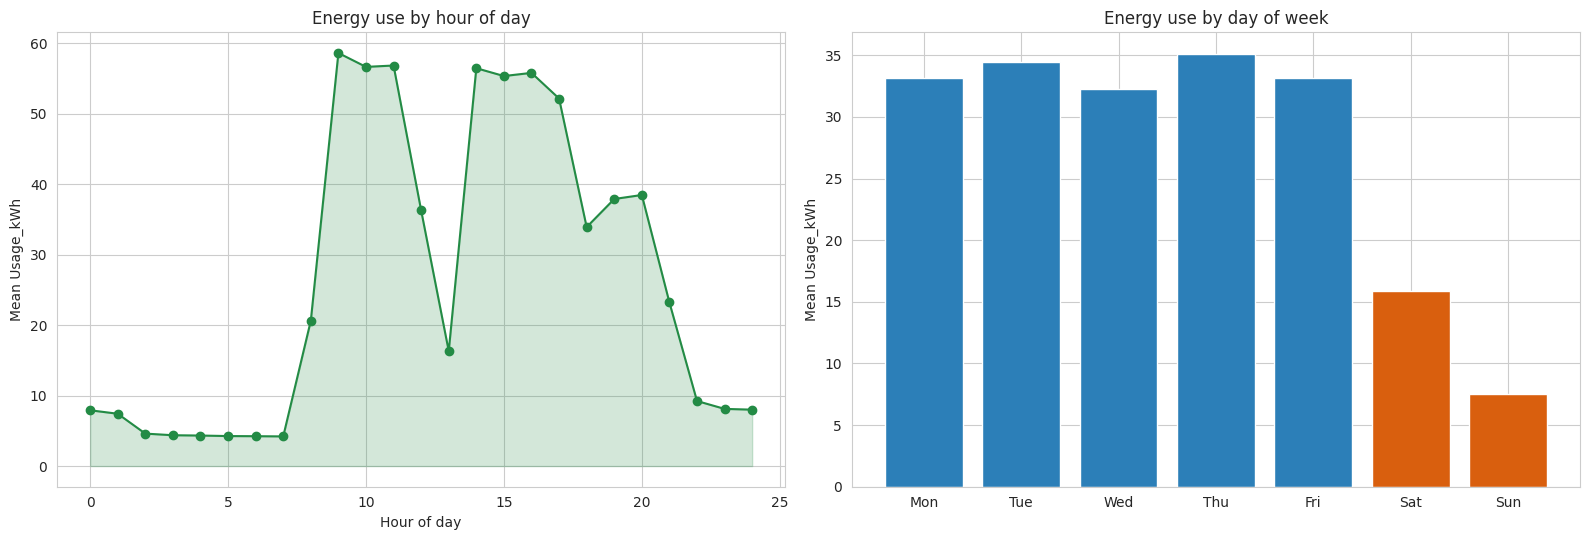

            count   mean
WeekStatus              
Weekday     25056  33.62
Weekend      9984  11.73


In [12]:
df["hour"] = df["NSM"] / 3600

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

hourly = df.groupby(df["hour"].round())["Usage_kWh"].mean()
axes[0].plot(hourly.index, hourly.values, marker="o", color="#238b45")
axes[0].fill_between(hourly.index, hourly.values, alpha=.2, color="#238b45")
axes[0].set(xlabel="Hour of day", ylabel="Mean Usage_kWh",
            title="Energy use by hour of day")

week_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
              "Friday", "Saturday", "Sunday"]
daily = df.groupby("Day_of_week")["Usage_kWh"].mean().reindex(week_order)
axes[1].bar(range(7), daily.values, color=["#2c7fb8"] * 5 + ["#d95f0e"] * 2)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels([d[:3] for d in week_order])
axes[1].set(ylabel="Mean Usage_kWh", title="Energy use by day of week")

plt.tight_layout()
plt.show()

print(df.groupby("WeekStatus")["Usage_kWh"].agg(["count", "mean"]).round(2))

**Answer Q1:** Consumption follows the production schedule. It is lowest overnight (≈4 kWh), climbs through the working day to a mid-day peak (≈55–60 kWh), and is far
lower at weekends (weekday mean ≈ 33.6 kWh vs weekend ≈ 11.7 kWh; Sunday lowest at
~7.6 kWh). Load-shifting and tariff planning should target the weekday daytime peak.

### Q2 — Which measurable electrical factors most strongly drive consumption?
Answered with the per-feature scatter plots against the target (non-linear shape) and
confirmed later by Random Forest importances in Phase 5.

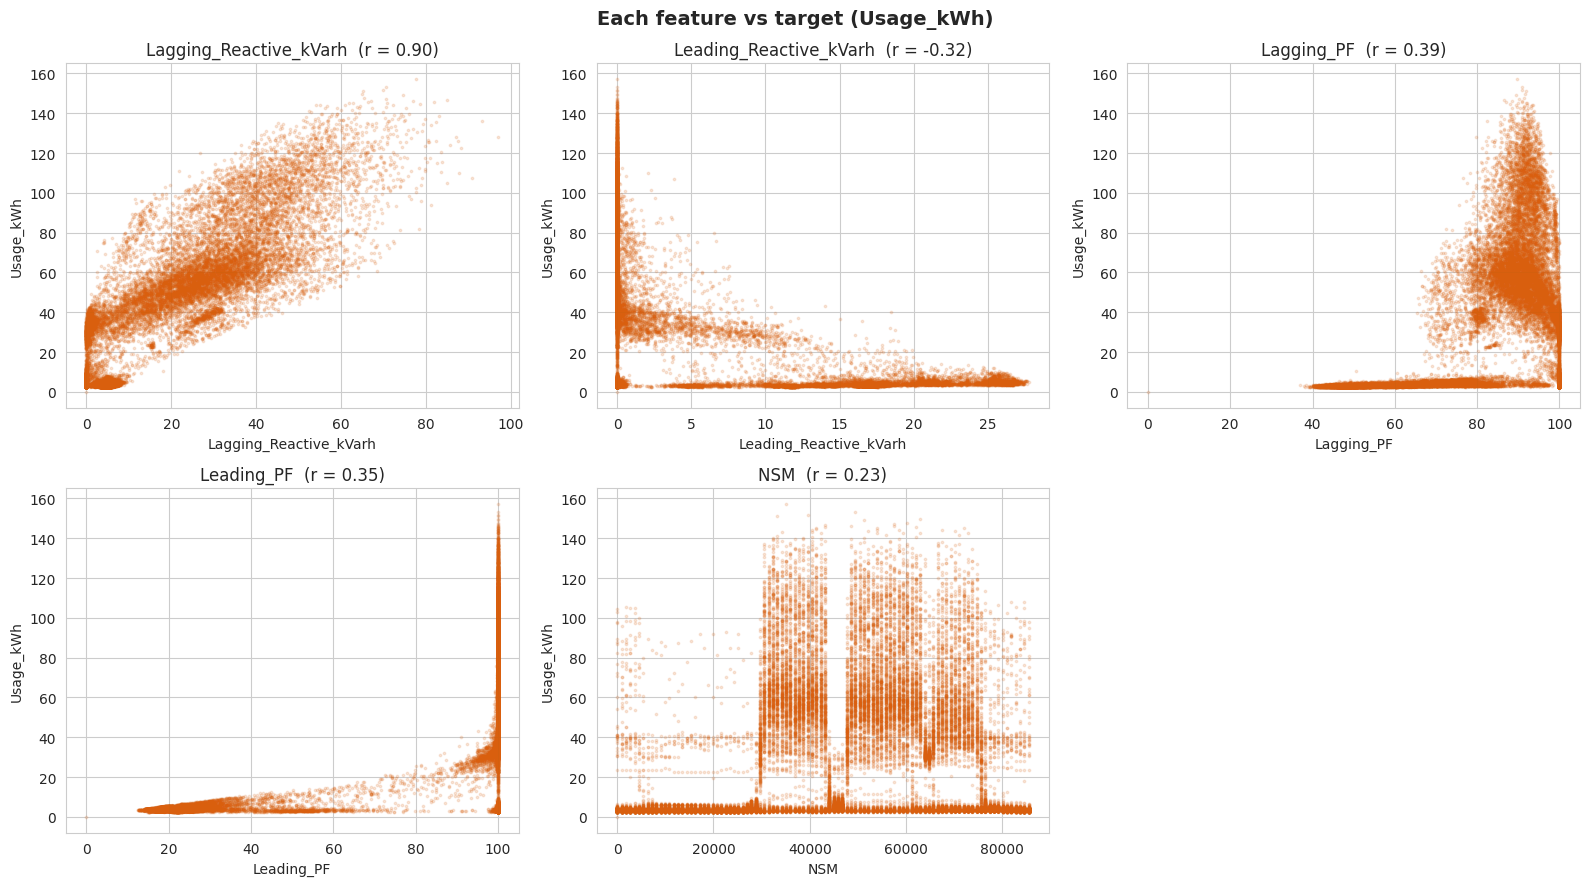

In [13]:
scatter_feats = ["Lagging_Reactive_kVarh", "Leading_Reactive_kVarh",
                 "Lagging_PF", "Leading_PF", "NSM"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, scatter_feats):
    ax.scatter(df[col], df[TARGET], s=3, alpha=.15, color="#d95f0e")
    ax.set(xlabel=col, ylabel=TARGET,
           title=f"{col}  (r = {df[col].corr(df[TARGET]):.2f})")
axes.flat[-1].axis("off")
plt.suptitle("Each feature vs target (Usage_kWh)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Answer Q2:** `Lagging_Reactive_kVarh` is by far the strongest legitimate driver
(r ≈ 0.90) — the inductive machinery that does real work also draws lagging reactive
power. The power factors and `NSM` show clearly **non-linear** relationships with the
target, which motivates trying a tree-based model (Q4).

### Q3 — Does the plant show power-factor inefficiency that signals avoidable cost?
Answered by relating leading reactive power / leading power factor to consumption.

In [14]:
idle = df["Usage_kWh"] < df["Usage_kWh"].median()
summary = pd.DataFrame({
    "Leading_Reactive_kVarh_mean": [df.loc[idle, "Leading_Reactive_kVarh"].mean(),
                                    df.loc[~idle, "Leading_Reactive_kVarh"].mean()],
    "Leading_PF_mean": [df.loc[idle, "Leading_PF"].mean(),
                        df.loc[~idle, "Leading_PF"].mean()],
}, index=["Low usage (idle-ish)", "High usage (producing)"])
print(summary.round(2))

share_leading = (df["Leading_Reactive_kVarh"] > 0).mean() * 100
print(f"\nIntervals with leading reactive power present: {share_leading:.0f}%")

                        Leading_Reactive_kVarh_mean  Leading_PF_mean
Low usage (idle-ish)                           4.80            76.82
High usage (producing)                         2.95            91.87

Intervals with leading reactive power present: 33%


**Answer Q3:** Leading reactive power appears almost exclusively during **low-usage /
idle** intervals — it reflects power-factor-correction capacitors over-compensating
when little is running (negative correlation with usage, r ≈ -0.32). The actionable
insight: capacitor banks are mistuned for idle periods, a classic source of avoidable
reactive-power penalties that plant operations can address by switching correction
off during downtime.

## Phase 4 — Modeling

Q4 is answered across Phases 4 and 5. We split the data, then fit a Linear Regression
baseline and a Random Forest.

### 4.1 Train / test split — 80 / 20, reproducible.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 28032 rows | Test: 7008 rows


### 4.2 A reusable evaluation helper (DRY)

In [16]:
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    """Fit a model, score it on the test set, and print the metrics.

    Parameters
    ----------
    name : str
        Human-readable model name for the printout.
    model : estimator
        Any scikit-learn regressor or pipeline implementing ``fit``/``predict``.
    X_tr, X_te : pandas.DataFrame
        Training and test feature matrices.
    y_tr, y_te : pandas.Series
        Training and test targets.

    Returns
    -------
    tuple(dict, estimator, numpy.ndarray)
        A metrics dict (R2, RMSE, MAE), the fitted model, and test predictions.
    """
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    metrics = {
        "Model": name,
        "R2": r2_score(y_te, pred),
        "RMSE": np.sqrt(mean_squared_error(y_te, pred)),
        "MAE": mean_absolute_error(y_te, pred),
    }
    print(f"{name:22s}  R2={metrics['R2']:.4f}  "
          f"RMSE={metrics['RMSE']:.3f}  MAE={metrics['MAE']:.3f}")
    return metrics, model, pred

### 4.3 Model 1 — Linear Regression (baseline)
Scaling is bundled into a pipeline so the standardized coefficients are comparable.

In [17]:
lin_metrics, lin_model, lin_pred = evaluate(
    "Linear Regression",
    make_pipeline(StandardScaler(), LinearRegression()),
    X_train, X_test, y_train, y_test)

Linear Regression       R2=0.9100  RMSE=10.114  MAE=6.989


### 4.4 Model 2 — Random Forest

In [18]:
rf_metrics, rf_model, rf_pred = evaluate(
    "Random Forest",
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    X_train, X_test, y_train, y_test)

Random Forest           R2=0.9997  RMSE=0.629  MAE=0.205


### 4.5 Cross-validation
A single split can be lucky; 5-fold CV confirms the Random Forest score is stable.

In [19]:
cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    X, y, cv=5, scoring="r2")
print(f"Random Forest 5-fold CV R2: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Random Forest 5-fold CV R2: 0.9992 +/- 0.0007


## Phase 5 — Evaluation

### 5.1 Results side by side

In [20]:
results = pd.DataFrame([lin_metrics, rf_metrics]).set_index("Model")
results.round(4)

,R2,RMSE,MAE
Model,,,
Linear Regression,0.9100,10.1139,6.9895
Random Forest,0.9997,0.6291,0.2054


### 5.2 Diagnostic plots (reusable, documented helpers)

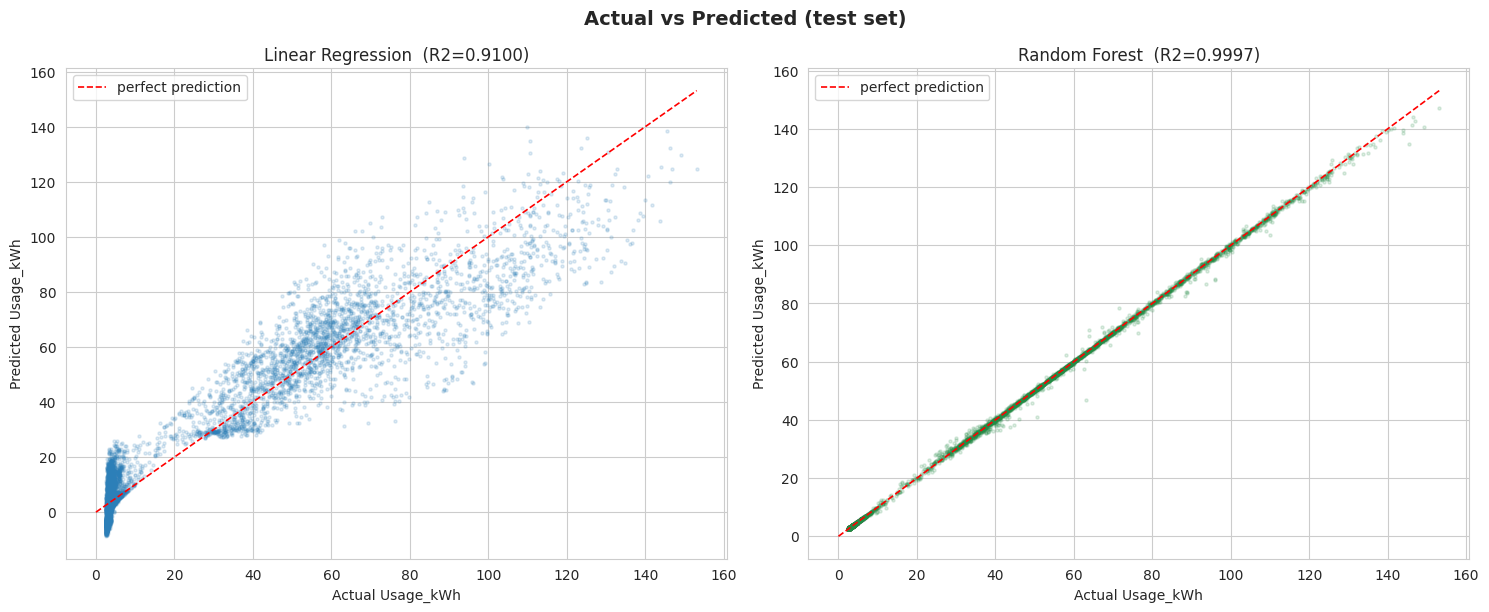

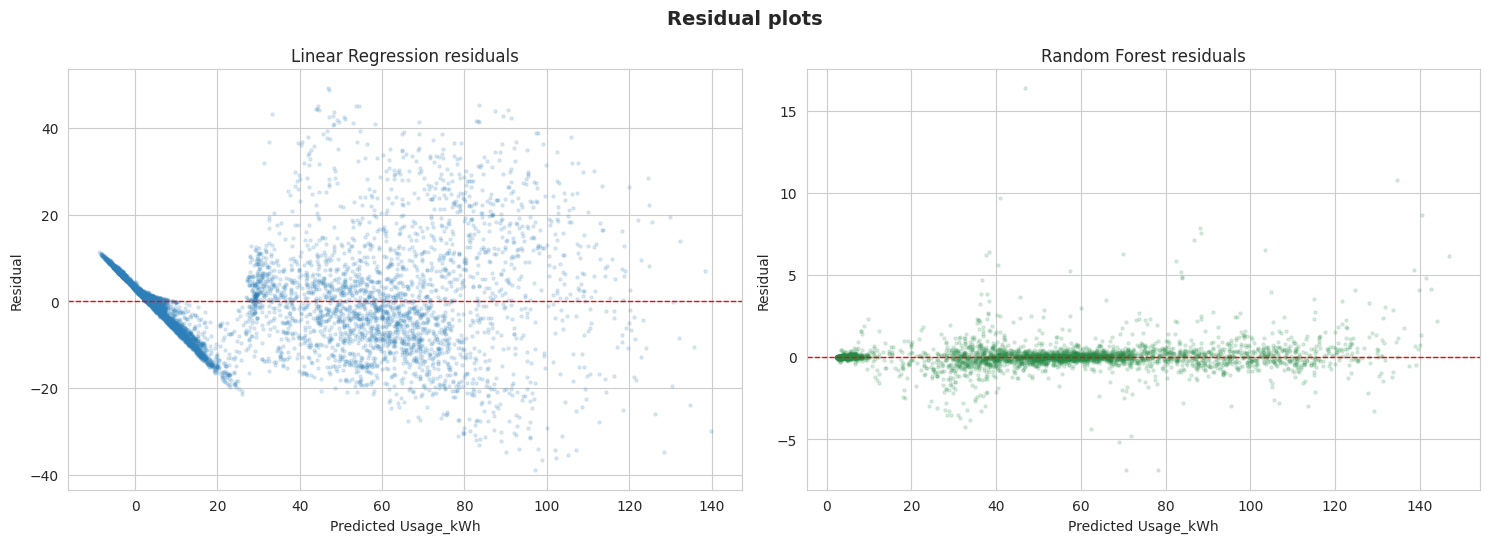

In [21]:
def plot_actual_vs_predicted(y_true, predictions, ax, title, color):
    """Scatter actual vs predicted values with a 45-degree reference line.

    Parameters
    ----------
    y_true : array-like
        Ground-truth target values.
    predictions : array-like
        Model predictions aligned with ``y_true``.
    ax : matplotlib.axes.Axes
        Axis to draw on.
    title : str
        Subplot title.
    color : str
        Marker colour.
    """
    ax.scatter(y_true, predictions, s=5, alpha=.15, color=color)
    limits = [0, max(y_true.max(), predictions.max())]
    ax.plot(limits, limits, "r--", lw=1.2, label="perfect prediction")
    ax.set(xlabel="Actual Usage_kWh", ylabel="Predicted Usage_kWh", title=title)
    ax.legend()


def plot_residuals(y_true, predictions, ax, title, color):
    """Plot residuals (actual - predicted) against predicted values.

    A well-behaved model shows a flat band centred on zero with no pattern.
    Parameters mirror :func:`plot_actual_vs_predicted`.
    """
    residuals = y_true - predictions
    ax.scatter(predictions, residuals, s=5, alpha=.15, color=color)
    ax.axhline(0, color="red", ls="--", lw=1)
    ax.set(xlabel="Predicted Usage_kWh", ylabel="Residual", title=title)


models_to_plot = [
    ("Linear Regression", lin_pred, "#2c7fb8"),
    ("Random Forest", rf_pred, "#238b45"),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))
for ax, (name, pred, color) in zip(axes, models_to_plot):
    plot_actual_vs_predicted(y_test, pred, ax,
                             f"{name}  (R2={r2_score(y_test, pred):.4f})", color)
plt.suptitle("Actual vs Predicted (test set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, (name, pred, color) in zip(axes, models_to_plot):
    plot_residuals(y_test, pred, ax, f"{name} residuals", color)
plt.suptitle("Residual plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 5.3 What each model learned

Random Forest feature importances:
Lagging_Reactive_kVarh    0.8711
Lagging_PF                0.0893
Leading_PF                0.0385
Leading_Reactive_kVarh    0.0009
NSM                       0.0002

Linear Regression standardized coefficients:
Lagging_Reactive_kVarh    24.016
Lagging_PF                13.316
Leading_PF                11.664
Leading_Reactive_kVarh     2.246
NSM                        1.711


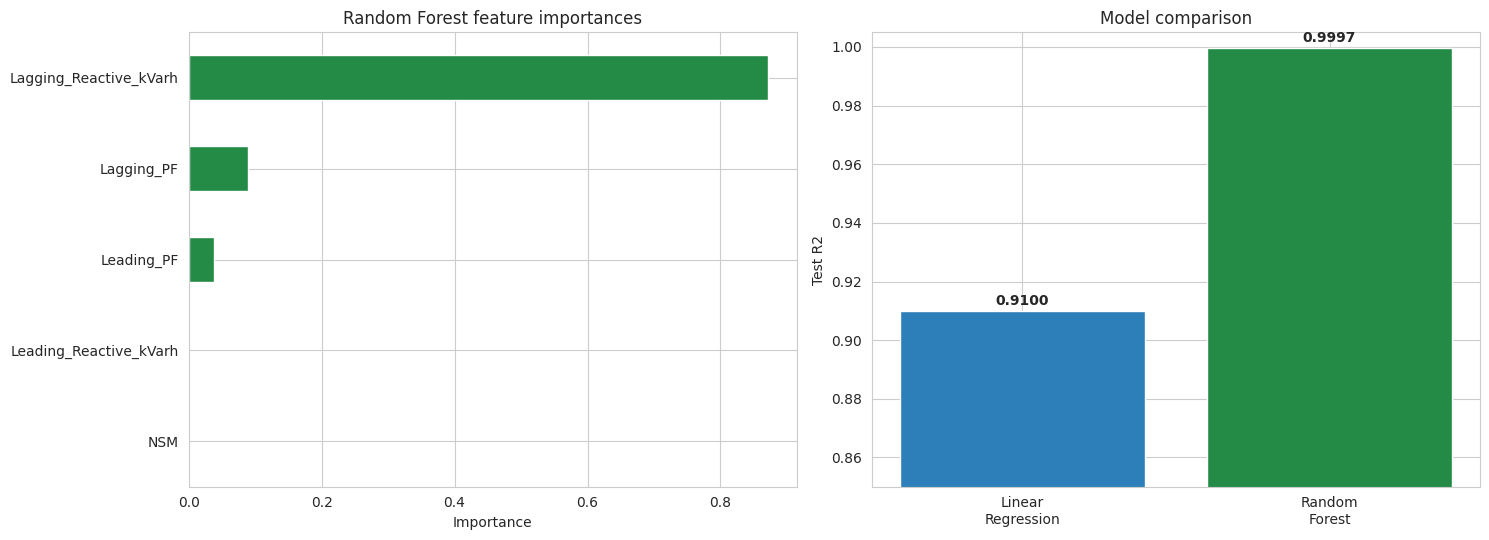

In [22]:
importances = (pd.Series(rf_model.feature_importances_, index=FEATURES)
                 .sort_values(ascending=False))
print("Random Forest feature importances:")
print(importances.round(4).to_string())

linear_step = lin_model.named_steps["linearregression"]
coefficients = (pd.Series(linear_step.coef_, index=FEATURES)
                  .sort_values(key=abs, ascending=False))
print("\nLinear Regression standardized coefficients:")
print(coefficients.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
importances.sort_values().plot.barh(ax=axes[0], color="#238b45")
axes[0].set(xlabel="Importance", title="Random Forest feature importances")

r2_values = [lin_metrics["R2"], rf_metrics["R2"]]
bars = axes[1].bar(["Linear\nRegression", "Random\nForest"], r2_values,
                   color=["#2c7fb8", "#238b45"])
axes[1].set(ylabel="Test R2", title="Model comparison", ylim=[0.85, 1.005])
for bar, value in zip(bars, r2_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, value + 0.002,
                 f"{value:.4f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

### 5.4 Why is the Random Forest almost perfect? (honest evaluation)

The Random Forest reaches **R² ≈ 0.9997 without CO2**, and cross-validation agrees, so
it is **not** overfitting. The cause is physics. Active power, reactive power and power
factor are three sides of the *power triangle*:

$$P_{active} = \frac{Q_{reactive}}{\tan(\arccos(\text{PF}))}$$

So `Lagging_Reactive_kVarh` and `Lagging_PF` together *algebraically determine* active
power — i.e. `Usage_kWh`. The cell below reconstructs the target from those two
features using only this formula, with **no machine learning**:

In [23]:
def reconstruct_usage(reactive_kvarh, power_factor_pct):
    """Reconstruct active energy from reactive power and power factor.

    Uses the power-triangle identity
    ``P = Q / tan(arccos(pf))`` where ``pf`` is the power factor as a fraction.

    Parameters
    ----------
    reactive_kvarh : array-like
        Lagging reactive power (kVarh).
    power_factor_pct : array-like
        Lagging power factor as a percentage (0-100).

    Returns
    -------
    numpy.ndarray
        Reconstructed active energy (comparable to Usage_kWh).
    """
    pf = np.clip(power_factor_pct / 100, 1e-6, 0.999999)
    tan_phi = np.sqrt(1 - pf ** 2) / pf
    return reactive_kvarh / tan_phi


reconstructed = reconstruct_usage(df["Lagging_Reactive_kVarh"], df["Lagging_PF"])
has_lagging = df["Lagging_Reactive_kVarh"] > 0

comparison = pd.DataFrame({
    "actual_Usage_kWh": df.loc[has_lagging, "Usage_kWh"].values,
    "physics_formula": reconstructed[has_lagging].values,
}).head(8)
print(comparison.round(2).to_string(index=False))
print(f"\nIdentity applies to {has_lagging.mean() * 100:.0f}% of rows "
      f"(those with lagging reactive power).")

 actual_Usage_kWh  physics_formula
             3.17             3.17
             4.00             4.00
             3.24             3.24
             3.31             3.31
             3.82             3.82
             3.28             3.28
             3.60             3.60
             3.60             3.60

Identity applies to 79% of rows (those with lagging reactive power).


The formula reproduces the target almost exactly with zero training. The Random
Forest simply learns this deterministic, non-linear relationship — which Linear
Regression cannot, because it is trigonometric rather than additive. The honest
reading: the ~0.91 R² of the linear model is the more informative figure for how much
a *simple additive* model explains.

### 5.5 Data-leakage demonstration — adding CO2 back
Adding CO2 lifts even the *linear* model from ~0.91 to ~0.98, confirming why it was
excluded in Phase 3.

In [24]:
features_with_co2 = FEATURES + ["CO2_tCO2"]
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    df[features_with_co2], y, test_size=0.2, random_state=42)

leak_metrics, _, _ = evaluate(
    "Linear Reg + CO2 (leaky)",
    make_pipeline(StandardScaler(), LinearRegression()),
    Xc_train, Xc_test, yc_train, yc_test)

print(f"\nHonest Linear Regression R2: {lin_metrics['R2']:.4f}")
print(f"With CO2 (leaky)        R2: {leak_metrics['R2']:.4f}")

Linear Reg + CO2 (leaky)  R2=0.9842  RMSE=4.240  MAE=2.517

Honest Linear Regression R2: 0.9100
With CO2 (leaky)        R2: 0.9842


### 5.6 Answers to the business questions

- **Q1 (timing):** demand tracks the shift schedule — low overnight and at weekends,
  peaking mid-day on weekdays (weekday ≈ 33.6 vs weekend ≈ 11.7 kWh). *Load-shift the
  weekday daytime peak.*
- **Q2 (drivers):** lagging reactive power is the dominant legitimate driver
  (r ≈ 0.90, 87% of Random Forest importance); relationships are non-linear.
- **Q3 (inefficiency):** leading reactive power flags capacitor over-correction during
  idle periods — an avoidable-penalty opportunity.
- **Q4 (prediction):** yes — Random Forest predicts to RMSE ≈ 0.6 kWh (R² ≈ 0.9997),
  but that ceiling reflects the power-triangle identity; a simple additive model
  explains ~91%.

## Phase 6 — Deployment

**How the results would be used.** The consumption model and the timing analysis feed
three practical uses:
1. **budgeting and load-shifting** — schedule heavy production
toward off-peak tariff windows identified in Q1.
2. **efficiency monitoring** — flag
intervals where leading reactive power indicates capacitor over-correction (Q3) to
reduce reactive-power penalties;
3. **automated consumption estimation** where direct
active-power metering is unavailable, using the reactive-power/power-factor
relationship (Q4).

**Caveats for deployment.** Because the electrical features partly *encode* the target
through electrical identities, this model is best understood as an accurate
*reconstruction / monitoring* tool rather than a forward *forecast*. A genuine demand
**forecast** (predicting future consumption before it happens) would restrict inputs
to information known ahead of time — calendar/time features and lagged usage — and is
the natural next iteration of this project.

---
### Summary table

| Model | Features | Test R² | RMSE (kWh) | Role |
|-------|----------|---------|------------|------|
| Linear Regression | 5 numeric (no CO2) | ~0.91 | ~10.1 | Honest additive baseline |
| Random Forest | 5 numeric (no CO2) | ~0.9997 | ~0.6 | Captures power-triangle identity (CV-confirmed) |
| Linear + CO2 | 6 (leaky) | ~0.98 | ~4.2 | Leakage illustration only — not valid |

### Libraries used
pandas, numpy, matplotlib, seaborn, scikit-learn, ucimlrepo.

### Acknowledgements
Dataset: V. E. Sathishkumar et al., *Steel Industry Energy Consumption*, UCI Machine
Learning Repository (id 851), DAEWOO Steel Co. Ltd, Gwangyang, South Korea.